
# ViT vs CNN — Paper‑Aligned End‑to‑End Notebook

This notebook merges your working pipeline with the following additions:
- **Cosine LR with warmup** (per‑step) and **early stopping**
- **SAM** optimizer wrapper (compatible with AdamW/SGD)
- **Layer‑wise LR Decay (LLRD)** for ViT
- **Conv‑stem** patch embed (optional locality bias) for ViT
- **Scratch ResNet‑18** experiment under the same augmentations
- **Recall‑first** model selection for screening (max precision at `recall ≥ target`)

It follows your data layout (`Data/chest_xray`) and keeps your *screening* evaluation strategy.


In [28]:

# --- Imports, device, paths, config ---
from dataclasses import dataclass
from pathlib import Path
import os, time, math, copy, random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets as tv_datasets, transforms, io as tv_io, models as tv_models

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             confusion_matrix, average_precision_score)

# Device (MPS on macOS if available)
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print("Device:", DEVICE)

# Paths (assuming this notebook lives in notebooks/)
REPO_ROOT   = Path.cwd().parent
DATASET_DIR = REPO_ROOT / "Data" / "chest_xray"
WEIGHTS_DIR = Path.cwd() / "weights"
WEIGHTS_DIR.mkdir(exist_ok=True, parents=True)
print("Dataset dir:", DATASET_DIR.resolve())
print("Weights dir:", WEIGHTS_DIR.resolve())

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

@dataclass
class Cfg:
    image_size: int = 224
    in_channels: int = 3
    batch_size: int = 32
    num_workers: int = 0
    use_stratified_val: bool = True
    stratified_val_size: float = 0.2

    # ViT small
    vit_embed_dim: int = 256
    vit_depth: int = 6
    vit_heads: int = 8
    vit_mlp_ratio: float = 4.0
    vit_drop: float = 0.1
    drop_path_rate: float = 0.05

    # Training
    scratch_epochs: int = 15
    scratch_lr: float = 3e-4
    scratch_wd: float = 5e-2
    pretrained_epochs: int = 10
    pretrained_lr: float = 1e-4
    pretrained_wd: float = 5e-2
    label_smoothing: float = 0.05
    patience: int = 5
    monitor: str = "va_auroc"
    target_recall: float = 0.95
    use_class_weights: bool = True

    # Optim/tricks
    use_sam: bool = True
    sam_rho_vit_small: float = 0.05
    sam_rho_cnn: float = 0.05
    use_cosine_warmup: bool = True
    warmup_epochs: int = 3
    vit_layer_decay: float = 0.75  # LLRD for ViT
    use_conv_stem: bool = False    # set True to add locality to ViT

    # Toggles
    run_vit_pretrained: bool = True   # only if weight file exists
    run_resnet_pretrained: bool = True

cfg = Cfg()
cfg


Device: mps
Dataset dir: /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/Data/chest_xray
Weights dir: /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/notebooks/weights


Cfg(image_size=224, in_channels=3, batch_size=32, num_workers=0, use_stratified_val=True, stratified_val_size=0.2, vit_embed_dim=256, vit_depth=6, vit_heads=8, vit_mlp_ratio=4.0, vit_drop=0.1, drop_path_rate=0.05, scratch_epochs=15, scratch_lr=0.0003, scratch_wd=0.05, pretrained_epochs=10, pretrained_lr=0.0001, pretrained_wd=0.05, label_smoothing=0.05, patience=5, monitor='va_auroc', target_recall=0.95, use_class_weights=True, use_sam=True, sam_rho_vit_small=0.05, sam_rho_cnn=0.05, use_cosine_warmup=True, warmup_epochs=3, vit_layer_decay=0.75, use_conv_stem=False, run_vit_pretrained=True, run_resnet_pretrained=True)

In [29]:

# --- Datasets & preprocessing ---
# Train: RandomResizedCrop(224) + HorizontalFlip(0.5)
# Val/Test: Resize(256) + CenterCrop(224)
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(cfg.image_size, scale=(0.08, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(cfg.image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

root = Path(DATASET_DIR)
ds_train_raw = tv_datasets.ImageFolder(root / 'train', transform=train_tf)
ds_val_raw   = tv_datasets.ImageFolder(root / 'val',   transform=eval_tf)
ds_test      = tv_datasets.ImageFolder(root / 'test',  transform=eval_tf)
classes = ds_train_raw.classes
print("Classes:", classes)

if cfg.use_stratified_val:
    # Merge official train + val and re‑split
    all_imgs = list(ds_train_raw.imgs) + list(ds_val_raw.imgs)
    all_targets = [y for (_,y) in all_imgs]
    all_paths   = [p for (p,_) in all_imgs]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=cfg.stratified_val_size, random_state=42)
    idx_train, idx_val = next(sss.split(np.zeros(len(all_targets)), all_targets))

    class _DS(torch.utils.data.Dataset):
        def __init__(self, paths, targets, transform):
            self.paths, self.targets, self.transform = paths, targets, transform
            self.samples = list(zip(paths, targets))
            self.classes = classes
            self.class_to_idx = {c:i for i,c in enumerate(classes)}
        def __len__(self): return len(self.paths)
        def __getitem__(self, i):
            p, y = self.paths[i], self.targets[i]
            im = tv_io.read_image(p).float()/255.0   # [C,H,W], C may be 1
            # enforce at least 224x224 and 3‑channel RGB
            im = transforms.functional.resize(im, [max(im.shape[1], cfg.image_size),
                                                   max(im.shape[2], cfg.image_size)])
            im = transforms.functional.center_crop(im, [cfg.image_size, cfg.image_size])
            im = transforms.functional.to_pil_image(im).convert("RGB")
            im = self.transform(im)
            return im, y

    train_ds = _DS([all_paths[i] for i in idx_train], [all_targets[i] for i in idx_train], train_tf)
    val_ds   = _DS([all_paths[i] for i in idx_val],   [all_targets[i] for i in idx_val],   eval_tf)
else:
    train_ds, val_ds = ds_train_raw, ds_val_raw

# Stats & loaders
train_counts = np.bincount([y for _,y in (train_ds.samples if hasattr(train_ds,'samples') else train_ds)])
print("Lens:", len(train_ds), len(val_ds), len(ds_test))
print("Train counts:", train_counts)

pin = True
if DEVICE.type == "mps":
    # MPS ignores pin_memory; harmless but we can set True, it will warn. Leave as is.
    pin = True

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=pin)
val_loader   = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=pin)
test_loader  = DataLoader(ds_test, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=pin)


Classes: ['NORMAL', 'PNEUMONIA']
Lens: 4185 1047 624
Train counts: [1079 3106]


In [30]:

# --- ViT building blocks (with DropPath) ---
import torch
import torch.nn as nn
import torch.nn.functional as F

class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob
    def forward(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep + torch.rand(shape, dtype=x.dtype, device=x.device)
        binary_mask = torch.floor(random_tensor)
        return (x / keep) * binary_mask

class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, drop=0.0):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.drop = nn.Dropout(drop)
    def forward(self, x):
        x = self.fc1(x); x = self.act(x); x = self.drop(x)
        x = self.fc2(x); x = self.drop(x)
        return x

class Attention(nn.Module):
    def __init__(self, dim, num_heads=8, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads)
        q, k, v = qkv.permute(2, 0, 3, 1, 4)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class Block(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, drop=0.0, drop_path=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), drop=drop)

    def forward(self, x):
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x

class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.num_patches = (img_size // patch_size) * (img_size // patch_size)
    def forward(self, x):
        x = self.proj(x)            # [B, D, H/ps, W/ps]
        x = x.flatten(2).transpose(1, 2)  # [B, N, D]
        return x

class ConvStemPatchEmbed(nn.Module):
    def __init__(self, img_size=224, in_chans=3, embed_dim=768, stem_channels=(64,64,128,256)):
        super().__init__()
        layers, c = [], in_chans
        for oc in stem_channels:
            layers += [nn.Conv2d(c, oc, 3, stride=2, padding=1, bias=False),
                       nn.BatchNorm2d(oc), nn.ReLU(inplace=True)]
            c = oc
        self.stem = nn.Sequential(*layers)
        self.proj = nn.Conv2d(c, embed_dim, 1)
        self.num_patches = (img_size // 16) * (img_size // 16)
    def forward(self, x):
        x = self.stem(x)      # [B, C, 14, 14] for 224
        x = self.proj(x)      # [B, D, 14, 14]
        x = x.flatten(2).transpose(1, 2)
        return x

class VisionTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, num_classes=2,
                 embed_dim=768, depth=12, num_heads=12, mlp_ratio=4.0,
                 drop_rate=0.0, drop_path_rate=0.0, use_conv_stem=False):
        super().__init__()
        self.embed_dim = embed_dim
        self.patch_embed = (ConvStemPatchEmbed(img_size, in_chans, embed_dim)
                            if use_conv_stem else
                            PatchEmbed(img_size, patch_size, in_chans, embed_dim))

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.patch_embed.num_patches, embed_dim))
        self.pos_drop = nn.Dropout(p=drop_rate)

        dpr = torch.linspace(0, drop_path_rate, steps=depth).tolist()
        self.blocks = nn.ModuleList([
            Block(embed_dim, num_heads, mlp_ratio, drop=drop_rate, drop_path=dpr[i])
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)                   # [B, N, D]
        cls = self.cls_token.expand(B, -1, -1)    # [B, 1, D]
        x = torch.cat((cls, x), dim=1) + self.pos_embed
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        cls_out = x[:, 0]
        return self.head(cls_out)


In [31]:

# === Training utilities: SAM, Cosine+Warmup, LLRD, evaluate ===
import inspect

class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        sig = inspect.signature(base_optimizer.__init__)
        valid = {k: v for k, v in kwargs.items() if k in sig.parameters}
        defaults = dict(rho=rho, **valid)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **valid)
        self.rho = rho

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = self.rho / (grad_norm + 1e-12)
            for p in group['params']:
                if p.grad is None: continue
                self.state[p]['old_p'] = p.data.clone()
                p.add_(p.grad * scale)
        if zero_grad:
            self.zero_grad(set_to_none=True)

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                p.data = self.state[p]['old_p']
        self.base_optimizer.step()
        if zero_grad:
            self.zero_grad(set_to_none=True)

    def step(self, closure=None):
        if closure is None:
            raise RuntimeError("SAM requires a closure")
        loss = closure()
        self.first_step(zero_grad=True)
        closure()
        self.second_step(zero_grad=True)
        return loss

    def zero_grad(self, set_to_none=True):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    def _grad_norm(self):
        device = self.param_groups[0]['params'][0].device
        norms = []
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                norms.append(torch.norm(p.grad.detach(), p=2).to(device))
        return torch.norm(torch.stack(norms), p=2) if norms else torch.tensor(0., device=device)

def make_criterion(class_weights=None, label_smoothing=0.0):
    w = class_weights.to(DEVICE) if class_weights is not None else None
    return nn.CrossEntropyLoss(weight=w, label_smoothing=label_smoothing)

def param_groups_lrd_vit(model, base_lr, weight_decay, layer_decay=0.75):
    no_wd_terms = ('pos_embed', 'cls_token', 'bias', 'norm')
    num_layers = len(getattr(model, 'blocks', []))
    def layer_id(n):
        if n.startswith('patch_embed'): return 0
        if n.startswith('blocks.'):
            return int(n.split('.')[1]) + 1
        return num_layers + 1
    groups = {}
    for n, p in model.named_parameters():
        if not p.requires_grad: continue
        l = layer_id(n)
        scale = layer_decay ** (num_layers + 1 - l)
        wd = 0.0 if any(k in n for k in no_wd_terms) or p.ndim < 2 else cfg.scratch_wd
        key = (l, wd)
        if key not in groups:
            groups[key] = {'params': [], 'lr': base_lr * scale, 'weight_decay': wd}
        groups[key]['params'].append(p)
    return list(groups.values())

def build_cosine_warmup(optimizer, steps_per_epoch, epochs, warmup_epochs=3):
    total_steps  = max(1, steps_per_epoch * epochs)
    warmup_steps = max(1, steps_per_epoch * warmup_epochs)
    def lr_lambda(step):
        if step < warmup_steps:
            return step / float(warmup_steps)
        t = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return 0.5 * (1.0 + math.cos(math.pi * t))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def train_model(model, train_loader, val_loader, device, epochs, base_lr, weight_decay,
                class_weights=None, monitor='va_auroc', patience=5,
                use_sam=False, sam_rho=0.05, tag='model',
                use_cosine_warmup=True, warmup_epochs=3, layer_decay=None):
    model = model.to(device)
    crit  = make_criterion(class_weights, cfg.label_smoothing)

    # Optim setup
    is_vit = isinstance(model, VisionTransformer) or hasattr(model, 'blocks')
    if is_vit:
        base_opt = torch.optim.AdamW
        params = param_groups_lrd_vit(model, base_lr, weight_decay, layer_decay) if layer_decay else model.parameters()
        base_kwargs = {'lr': base_lr, 'weight_decay': weight_decay}
    else:
        base_opt = torch.optim.SGD
        params = model.parameters()
        base_kwargs = {'lr': base_lr, 'weight_decay': weight_decay, 'momentum': 0.9}

    if use_sam:
        sig = inspect.signature(base_opt.__init__)
        valid = {k: v for k, v in base_kwargs.items() if k in sig.parameters}
        opt = SAM(params, base_opt, rho=sam_rho, **valid)
    else:
        opt = base_opt(params, **base_kwargs)

    scheduler = None
    if use_cosine_warmup:
        scheduler = build_cosine_warmup(opt, steps_per_epoch=max(1, len(train_loader)),
                                        epochs=epochs, warmup_epochs=warmup_epochs)

    best_state = None; best_metric = -1e9; no_imp = 0
    hist = {'tr_loss':[], 'va_loss':[], 'va_acc':[], 'va_f1':[], 'va_auroc':[]}
    global_step = 0
    for ep in range(1, epochs+1):
        model.train(); tr_losses=[]
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            if use_sam:
                def closure():
                    opt.zero_grad(set_to_none=True)
                    logits = model(xb); loss = crit(logits, yb)
                    loss.backward()
                    return loss
                loss = opt.step(closure)
                tr_losses.append(loss.item())
            else:
                logits = model(xb); loss = crit(logits, yb)
                opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
                tr_losses.append(loss.item())
            if scheduler is not None: scheduler.step()
            global_step += 1

        # Validation
        model.eval(); va_losses=[]; preds=[]; targs=[]
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb); va_losses.append(crit(out, yb).item())
                p = F.softmax(out, dim=1)[:,1].detach().cpu().numpy()
                preds.append(p); targs.append(yb.cpu().numpy())
        preds = np.concatenate(preds); targs = np.concatenate(targs)
        yhat = (preds >= 0.5).astype(int)
        va_acc = accuracy_score(targs, yhat)
        va_f1  = f1_score(targs, yhat, zero_division=0)
        try: va_auroc = roc_auc_score(targs, preds)
        except: va_auroc = float('nan')

        hist['tr_loss'].append(float(np.mean(tr_losses)))
        hist['va_loss'].append(float(np.mean(va_losses)))
        hist['va_acc'].append(float(va_acc))
        hist['va_f1'].append(float(va_f1))
        hist['va_auroc'].append(float(va_auroc))

        metric = va_auroc if monitor=='va_auroc' else va_f1
        if metric > best_metric:
            best_metric = metric; best_state = copy.deepcopy(model.state_dict()); no_imp=0
        else:
            no_imp += 1
        print(f"[{tag}] epoch {ep:02d}/{epochs:02d}  tr_loss={np.mean(tr_losses):.4f}  "
              f"val_loss={np.mean(va_losses):.4f}  val_acc={va_acc:.4f}  val_f1={va_f1:.4f}  "
              f"val_auroc={va_auroc:.4f}  (no_improve={no_imp})")
        if no_imp >= patience:
            print(f"[{tag}] early stopping at epoch {ep}."); break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, hist, float(global_step)

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval(); probs=[]; targs=[]; logits_all=[]
    for xb, yb in loader:
        xb = xb.to(device)
        out = model(xb); logits_all.append(out.detach().cpu().numpy())
        p = F.softmax(out, dim=1)[:,1].detach().cpu().numpy()
        probs.append(p); targs.append(yb.numpy())
    probs = np.concatenate(probs); targs = np.concatenate(targs); logits = np.concatenate(logits_all)
    return {'targets': targs, 'probs': np.stack([1-probs, probs], 1), 'logits': logits,
            'auroc': roc_auc_score(targs, probs)}


In [32]:

# --- Metrics: threshold selection (recall‑first), summaries, plots ---
def choose_threshold_by_min_recall_full(y, p1, min_recall=0.95):
    prec, rec, thr = precision_recall_curve(y, p1)
    cands = [(t, r, p) for t, r, p in zip(thr, rec[:-1], prec[:-1]) if r >= min_recall]
    if not cands:
        # fallback to min thr (max recall)
        t = float(thr.min() if len(thr) else 0.5)
        from sklearn.metrics import f1_score
        yhat = (p1 >= t).astype(int)
        return t, float(rec.max() if len(rec) else 1.0), float(prec[0] if len(prec) else 1.0), float(f1_score(y, yhat))
    # pick highest precision, then lower thr
    cands.sort(key=lambda z: (-z[2], z[0]))
    t, r, p = cands[0]
    from sklearn.metrics import f1_score
    yhat = (p1 >= t).astype(int)
    f1 = f1_score(y, yhat, zero_division=0)
    return float(t), float(r), float(p), float(f1)

def summarize_at_threshold(y, p1, thr):
    yhat = (p1 >= thr).astype(int)
    return {
        "acc": float(accuracy_score(y, yhat)),
        "precision": float(precision_score(y, yhat, zero_division=0)),
        "recall": float(recall_score(y, yhat, zero_division=0)),
        "f1": float(f1_score(y, yhat, zero_division=0)),
        "auroc": float(roc_auc_score(y, p1)),
        "thr": float(thr),
    }

def plot_curve(tr, va, title):
    xs = range(len(tr))
    plt.figure(figsize=(6,4))
    plt.plot(xs, tr, label='train')
    plt.plot(xs, va, label='val')
    plt.title(title); plt.xlabel('epoch'); plt.legend(); plt.tight_layout(); plt.show()

def plot_two_series(a, a_name, b, b_name, title):
    xs = range(len(a))
    plt.figure(figsize=(6,4))
    plt.plot(xs, a, label=a_name)
    plt.plot(xs, b, label=b_name)
    plt.title(title); plt.xlabel('epoch'); plt.legend(); plt.tight_layout(); plt.show()

def diag_plots(model_name, probs, y_true, thr, auroc=None, class_names=None):
    from sklearn.metrics import confusion_matrix, roc_curve, average_precision_score
    y_hat = (probs[:,1] >= thr).astype(int)
    cm = confusion_matrix(y_true, y_hat)
    labels = class_names or ['NORMAL','PNEUMONIA']

    # Confusion matrix
    plt.figure(figsize=(4,4))
    plt.imshow(cm, interpolation='nearest'); plt.title(f"{model_name} — Confusion (cal)")
    plt.colorbar(); ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=45); plt.yticks(ticks, labels)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()

    # ROC
    fpr, tpr, _ = roc_curve(y_true, probs[:,1])
    from sklearn.metrics import roc_auc_score
    auroc = roc_auc_score(y_true, probs[:,1]) if auroc is None else auroc
    plt.figure(figsize=(5,4)); plt.plot(fpr, tpr, lw=2); plt.plot([0,1],[0,1],'--')
    plt.title(f"{model_name} — ROC (AUROC={auroc:.4f})"); plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.tight_layout(); plt.show()

    # PR
    prec, rec, _ = precision_recall_curve(y_true, probs[:,1])
    ap = average_precision_score(y_true, probs[:,1])
    plt.figure(figsize=(5,4)); plt.plot(rec, prec, lw=2)
    plt.title(f"{model_name} — PR (AP={ap:.4f})"); plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.tight_layout(); plt.show()


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[vit_scratch] epoch 01/15  tr_loss=0.7053  val_loss=0.6955  val_acc=0.7182  val_f1=0.8329  val_auroc=0.5879  (no_improve=0)


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[vit_scratch] epoch 02/15  tr_loss=0.7046  val_loss=0.6900  val_acc=0.3878  val_f1=0.3274  val_auroc=0.5887  (no_improve=0)


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

[vit_scratch] epoch 13/15  tr_loss=0.6819  val_loss=0.6749  val_acc=0.5081  val_f1=0.5502  val_auroc=0.6408  (no_improve=0)


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[vit_scratch] epoch 14/15  tr_loss=0.6783  val_loss=0.6733  val_acc=0.5043  val_f1=0.5443  val_auroc=0.6429  (no_improve=0)


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[vit_scratch] epoch 15/15  tr_loss=0.6770  val_loss=0.6729  val_acc=0.4947  val_f1=0.5281  val_auroc=0.6444  (no_improve=0)


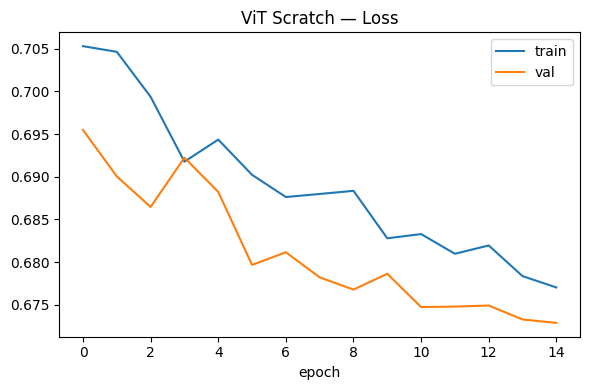

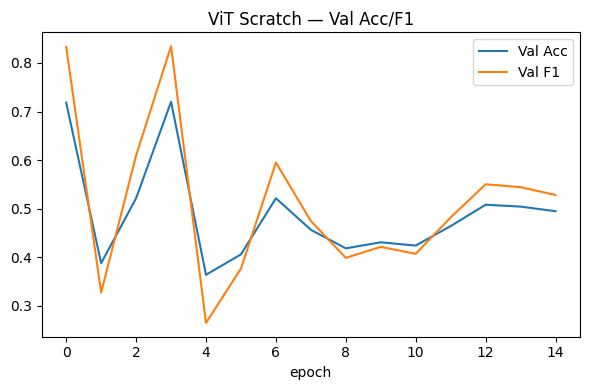

/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[ViT Scratch] chosen thr on VAL: 0.434 (VAL recall=0.972, precision=0.750)


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[ViT Scratch @0.5]  {'acc': 0.6186, 'precision': 0.6246, 'recall': 0.9769, 'f1': 0.762, 'auroc': 0.7175, 'thr': 0.5}
[ViT Scratch @Rec]  {'acc': 0.625, 'precision': 0.625, 'recall': 1.0, 'f1': 0.7692, 'auroc': 0.7175, 'thr': 0.4339}


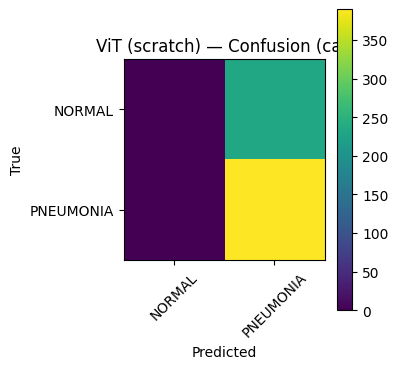

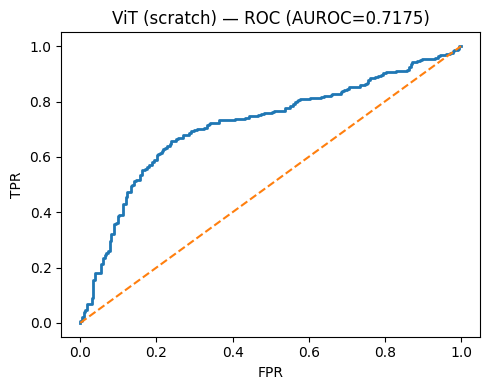

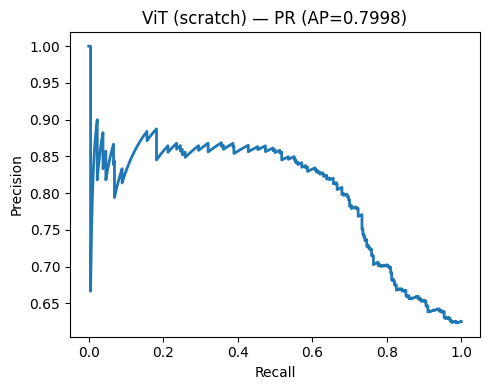

In [33]:

# === EXPERIMENT A: ViT (scratch) — cosine+warmup, LLRD, optional conv‑stem & SAM ===
vit_scratch = VisionTransformer(
    img_size=cfg.image_size, patch_size=16, in_chans=cfg.in_channels, num_classes=2,
    embed_dim=cfg.vit_embed_dim, depth=cfg.vit_depth, num_heads=cfg.vit_heads,
    mlp_ratio=cfg.vit_mlp_ratio, drop_rate=cfg.vit_drop, drop_path_rate=cfg.drop_path_rate,
    use_conv_stem=cfg.use_conv_stem
).to(DEVICE)

# Class weights (to mitigate imbalance)
cw = None
if cfg.use_class_weights:
    arr = np.array(train_counts, dtype=float)
    w = arr.sum() / (len(arr) * (arr + 1e-9))
    cw = torch.tensor(w, dtype=torch.float32)

vit_scratch, hist_s, steps_s = train_model(
    vit_scratch, train_loader, val_loader, DEVICE,
    epochs=cfg.scratch_epochs, base_lr=cfg.scratch_lr, weight_decay=cfg.scratch_wd,
    class_weights=cw, monitor=cfg.monitor, patience=cfg.patience, tag='vit_scratch',
    use_sam=cfg.use_sam, sam_rho=cfg.sam_rho_vit_small,
    use_cosine_warmup=cfg.use_cosine_warmup, warmup_epochs=cfg.warmup_epochs,
    layer_decay=cfg.vit_layer_decay
)

plot_curve(hist_s['tr_loss'], hist_s['va_loss'], 'ViT Scratch — Loss')
plot_two_series(hist_s['va_acc'], 'Val Acc', hist_s['va_f1'], 'Val F1', 'ViT Scratch — Val Acc/F1')

# Recall‑first: choose threshold on VAL, evaluate on TEST
val_s = evaluate(vit_scratch, val_loader, DEVICE)
thr_s, rec_s, prec_s, f1_s = choose_threshold_by_min_recall_full(val_s['targets'], val_s['probs'][:,1], cfg.target_recall)
print(f"[ViT Scratch] chosen thr on VAL: {thr_s:.3f} (VAL recall={rec_s:.3f}, precision={prec_s:.3f})")

test_s = evaluate(vit_scratch, test_loader, DEVICE)
y_test_s = test_s['targets']; p1_test_s = test_s['probs'][:,1]
summary_s_05   = summarize_at_threshold(y_test_s, p1_test_s, 0.5)
summary_s_reca = summarize_at_threshold(y_test_s, p1_test_s, thr_s)
print('[ViT Scratch @0.5] ', {k: round(v,4) for k,v in summary_s_05.items()})
print('[ViT Scratch @Rec] ', {k: round(v,4) for k,v in summary_s_reca.items()})

diag_plots('ViT (scratch)', test_s['probs'], y_test_s, thr_s, auroc=test_s.get('auroc'), class_names=classes)

vit_scratch_results = {
    'summary@0.5': summary_s_05, 'summary@recall': summary_s_reca,
    'threshold': float(thr_s), 'time_sec': steps_s,  # steps as proxy; replace with wall time if needed
    'params': sum(p.numel() for p in vit_scratch.parameters())
}


Loaded Google ViT‑B/16 .npz weights.


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[vit_google_npz_pretrained_sam] epoch 01/10  tr_loss=0.6085  val_loss=0.3996  val_acc=0.8854  val_f1=0.9174  val_auroc=0.9601  (no_improve=0)


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[vit_google_npz_pretrained_sam] epoch 02/10  tr_loss=0.2847  val_loss=0.2673  val_acc=0.9102  val_f1=0.9361  val_auroc=0.9934  (no_improve=0)


...

[vit_google_npz_pretrained_sam] epoch 08/10  tr_loss=0.1950  val_loss=0.1779  val_acc=0.9933  val_f1=0.9955  val_auroc=0.9992  (no_improve=2)


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[vit_google_npz_pretrained_sam] epoch 09/10  tr_loss=0.1970  val_loss=0.1788  val_acc=0.9933  val_f1=0.9955  val_auroc=0.9992  (no_improve=3)


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[vit_google_npz_pretrained_sam] epoch 10/10  tr_loss=0.1911  val_loss=0.1786  val_acc=0.9933  val_f1=0.9955  val_auroc=0.9993  (no_improve=0)


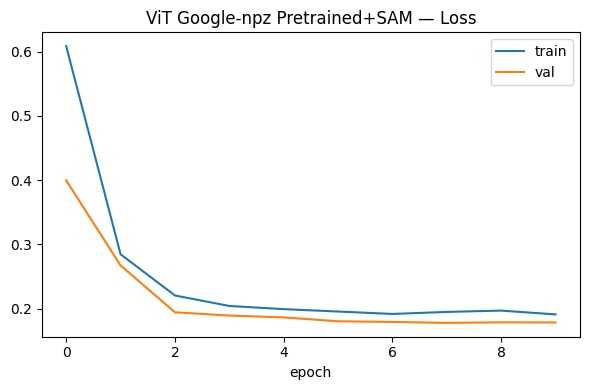

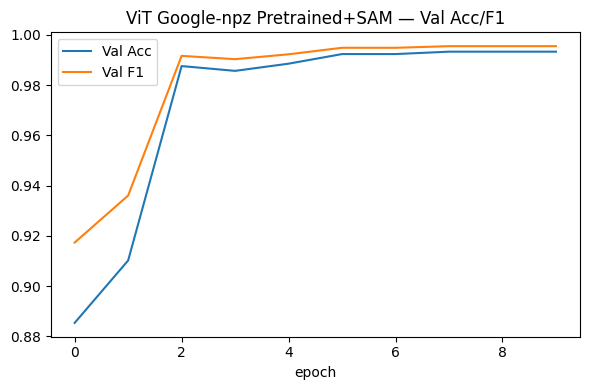

/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[ViT Pretrained+SAM] chosen thr on VAL: 0.875 (VAL recall=0.951, precision=0.999)


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[ViT Pretrained+SAM @0.5] {'acc': 0.625, 'precision': 0.625, 'recall': 1.0, 'f1': 0.7692, 'auroc': 0.595, 'thr': 0.5}
[ViT Pretrained+SAM @Rec] {'acc': 0.625, 'precision': 0.6254, 'recall': 0.9974, 'f1': 0.7688, 'auroc': 0.595, 'thr': 0.8755}


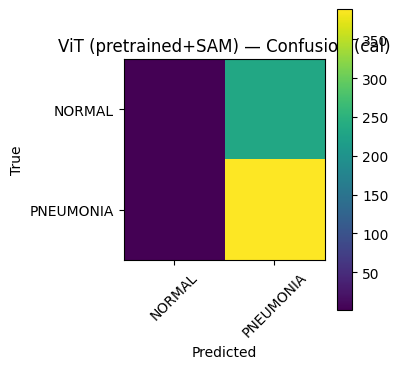

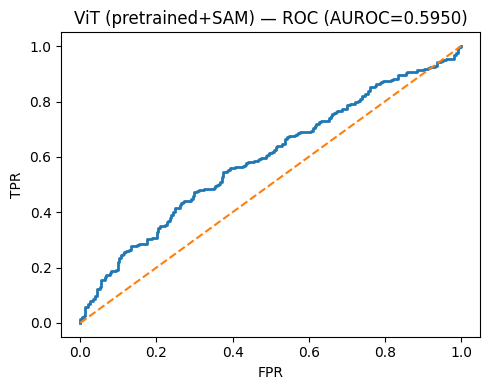

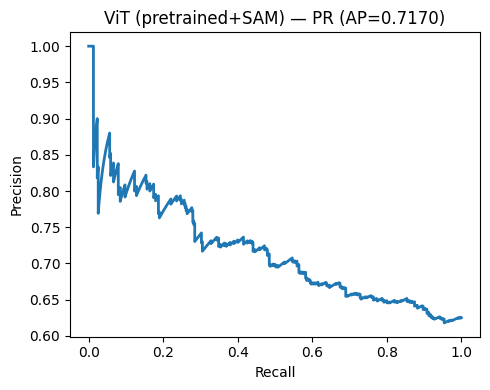

In [34]:

# === EXPERIMENT B: ViT‑B/16 (Google .npz) + SAM (runs only if weight file exists) ===
NPZ_PATH = WEIGHTS_DIR / "ViT-B_16.npz"

@torch.no_grad()
def _get_any(w, keys):
    for k in keys:
        if k in w: return w[k]
    raise KeyError(f"None of keys found: {keys}")

@torch.no_grad()
def load_jax_vit_npz_into_pytorch(model, npz_path: str | Path):
    w = np.load(str(npz_path))
    D = model.head.in_features

    def n2t(x): return torch.from_numpy(x).float()

    # Patch embedding
    model.patch_embed.proj.weight.copy_(n2t(w['embedding/kernel']).permute(3,2,0,1))
    model.patch_embed.proj.bias.copy_(n2t(w['embedding/bias']))

    # CLS + pos emb (with interpolation if needed)
    model.cls_token.copy_(n2t(w['cls']))
    posemb = w['Transformer/posembed_input/pos_embedding']
    if posemb.shape[1] != model.pos_embed.shape[1]:
        cls_pos = posemb[:, :1]
        grid_pos = posemb[:, 1:]
        gs_old = int(np.sqrt(grid_pos.shape[1]))
        grid_pos = grid_pos.reshape(1, gs_old, gs_old, D).transpose(0,3,1,2)
        H = W = int((model.patch_embed.num_patches) ** 0.5)
        grid_pos = F.interpolate(n2t(grid_pos), size=(H, W), mode='bicubic', align_corners=False)
        grid_pos = grid_pos.permute(0,2,3,1).reshape(1, H*W, D).numpy()
        posemb = np.concatenate([cls_pos, grid_pos], axis=1)
    model.pos_embed.copy_(n2t(posemb))

    def flatten_qkv(W, b):
        if W.ndim == 3: W = W.reshape(W.shape[0], -1)
        b = b.reshape(-1); return W, b
    def flatten_out(Wo):
        if Wo.ndim == 3: Wo = Wo.reshape(-1, Wo.shape[-1])
        return Wo.T

    for i, blk in enumerate(model.blocks):
        blk.norm1.weight.copy_(n2t(_get_any(w, [f'Transformer/encoderblock_{i}/LayerNorm_0/scale'])))
        blk.norm1.bias.copy_(n2t(_get_any(w,  [f'Transformer/encoderblock_{i}/LayerNorm_0/bias'])))
        blk.norm2.weight.copy_(n2t(_get_any(w, [f'Transformer/encoderblock_{i}/LayerNorm_2/scale'])))
        blk.norm2.bias.copy_(n2t(_get_any(w,  [f'Transformer/encoderblock_{i}/LayerNorm_2/bias'])))

        Wq = _get_any(w, [f'Transformer/encoderblock_{i}/MultiHeadDotProductAttention_1/query/kernel'])
        bq = _get_any(w, [f'Transformer/encoderblock_{i}/MultiHeadDotProductAttention_1/query/bias'])
        Wk = _get_any(w, [f'Transformer/encoderblock_{i}/MultiHeadDotProductAttention_1/key/kernel'])
        bk = _get_any(w, [f'Transformer/encoderblock_{i}/MultiHeadDotProductAttention_1/key/bias'])
        Wv = _get_any(w, [f'Transformer/encoderblock_{i}/MultiHeadDotProductAttention_1/value/kernel'])
        bv = _get_any(w, [f'Transformer/encoderblock_{i}/MultiHeadDotProductAttention_1/value/bias'])
        Wq, bq = flatten_qkv(Wq, bq)
        Wk, bk = flatten_qkv(Wk, bk)
        Wv, bv = flatten_qkv(Wv, bv)
        Wqkv = np.concatenate([Wq, Wk, Wv], axis=1).T
        bqkv = np.concatenate([bq, bk, bv], axis=0)
        blk.attn.qkv.weight.copy_(n2t(Wqkv))
        blk.attn.qkv.bias.copy_(n2t(bqkv))

        Wo = _get_any(w, [f'Transformer/encoderblock_{i}/MultiHeadDotProductAttention_1/out/kernel'])
        bo = _get_any(w, [f'Transformer/encoderblock_{i}/MultiHeadDotProductAttention_1/out/bias'])
        blk.attn.proj.weight.copy_(n2t(flatten_out(Wo)))
        blk.attn.proj.bias.copy_(n2t(bo))

        # Support both key schemes: 'Mlp/Dense_0' or 'MlpBlock_3/Dense_0'
        Wm0 = _get_any(w, [f'Transformer/encoderblock_{i}/Mlp/Dense_0/kernel',
                           f'Transformer/encoderblock_{i}/MlpBlock_3/Dense_0/kernel'])
        bm0 = _get_any(w, [f'Transformer/encoderblock_{i}/Mlp/Dense_0/bias',
                           f'Transformer/encoderblock_{i}/MlpBlock_3/Dense_0/bias'])
        Wm1 = _get_any(w, [f'Transformer/encoderblock_{i}/Mlp/Dense_1/kernel',
                           f'Transformer/encoderblock_{i}/MlpBlock_3/Dense_1/kernel'])
        bm1 = _get_any(w, [f'Transformer/encoderblock_{i}/Mlp/Dense_1/bias',
                           f'Transformer/encoderblock_{i}/MlpBlock_3/Dense_1/bias'])
        blk.mlp.fc1.weight.copy_(n2t(Wm0).T); blk.mlp.fc1.bias.copy_(n2t(bm0))
        blk.mlp.fc2.weight.copy_(n2t(Wm1).T); blk.mlp.fc2.bias.copy_(n2t(bm1))

    model.norm.weight.copy_(n2t(w['Transformer/encoder_norm/scale']))
    model.norm.bias.copy_(n2t(w['Transformer/encoder_norm/bias']))
    return model

vit_pretrained_results = None
if cfg.run_vit_pretrained and NPZ_PATH.exists():
    vit_b16 = VisionTransformer(
        img_size=cfg.image_size, patch_size=16, in_chans=3, num_classes=2,
        embed_dim=768, depth=12, num_heads=12, mlp_ratio=4.0, drop_rate=0.0, drop_path_rate=0.0
    ).to(DEVICE)

    vit_b16 = load_jax_vit_npz_into_pytorch(vit_b16, NPZ_PATH)
    print("Loaded Google ViT‑B/16 .npz weights.")

    cw = None
    if cfg.use_class_weights:
        arr = np.array(train_counts, dtype=float)
        w = arr.sum() / (len(arr) * (arr + 1e-9))
        cw = torch.tensor(w, dtype=torch.float32)

    vit_b16, hist_pt, steps_pt = train_model(
        vit_b16, train_loader, val_loader, DEVICE,
        epochs=cfg.pretrained_epochs, base_lr=cfg.pretrained_lr, weight_decay=cfg.pretrained_wd,
        class_weights=cw, monitor=cfg.monitor, patience=cfg.patience, tag="vit_google_npz_pretrained_sam",
        use_sam=cfg.use_sam, sam_rho=cfg.sam_rho_vit_small,
        use_cosine_warmup=cfg.use_cosine_warmup, warmup_epochs=cfg.warmup_epochs,
        layer_decay=cfg.vit_layer_decay
    )

    plot_curve(hist_pt['tr_loss'], hist_pt['va_loss'], 'ViT Google‑npz Pretrained+SAM — Loss')
    plot_two_series(hist_pt['va_acc'], 'Val Acc', hist_pt['va_f1'], 'Val F1',
                    'ViT Google‑npz Pretrained+SAM — Val Acc/F1')

    val_p = evaluate(vit_b16, val_loader, DEVICE)
    thr_p, rec_p, prec_p, f1p = choose_threshold_by_min_recall_full(val_p['targets'], val_p['probs'][:,1], cfg.target_recall)
    print(f"[ViT Pretrained+SAM] chosen thr on VAL: {thr_p:.3f} (VAL recall={rec_p:.3f}, precision={prec_p:.3f})")

    test_p = evaluate(vit_b16, test_loader, DEVICE)
    y_test = test_p['targets']; p1_test = test_p['probs'][:,1]
    summary_p_05   = summarize_at_threshold(y_test, p1_test, 0.5)
    summary_p_reca = summarize_at_threshold(y_test, p1_test, thr_p)
    print("[ViT Pretrained+SAM @0.5]", {k: round(v,4) for k,v in summary_p_05.items()})
    print("[ViT Pretrained+SAM @Rec]", {k: round(v,4) for k,v in summary_p_reca.items()})

    diag_plots("ViT (pretrained+SAM)", test_p["probs"], y_test, thr_p, auroc=test_p.get("auroc"), class_names=classes)

    vit_pretrained_results = {
        "summary@0.5": summary_p_05, "summary@recall": summary_p_reca,
        "threshold": float(thr_p), "time_sec": steps_pt,
        "params": sum(p.numel() for p in vit_b16.parameters())
    }
else:
    print(f"Skip ViT‑B/16 pretrained: file not found -> {NPZ_PATH}")


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[resnet18_scratch] epoch 01/15  tr_loss=0.6424  val_loss=1.3647  val_acc=0.3190  val_f1=0.1562  val_auroc=0.7092  (no_improve=0)


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[resnet18_scratch] epoch 02/15  tr_loss=0.5367  val_loss=1.2286  val_acc=0.2808  val_f1=0.0599  val_auroc=0.5396  (no_improve=1)


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

[resnet18_scratch] epoch 13/15  tr_loss=0.4478  val_loss=0.4583  val_acc=0.7832  val_f1=0.8305  val_auroc=0.9098  (no_improve=0)


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[resnet18_scratch] epoch 14/15  tr_loss=0.4446  val_loss=0.4396  val_acc=0.8109  val_f1=0.8557  val_auroc=0.9130  (no_improve=0)


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[resnet18_scratch] epoch 15/15  tr_loss=0.4506  val_loss=0.4330  val_acc=0.8424  val_f1=0.8850  val_auroc=0.9002  (no_improve=1)


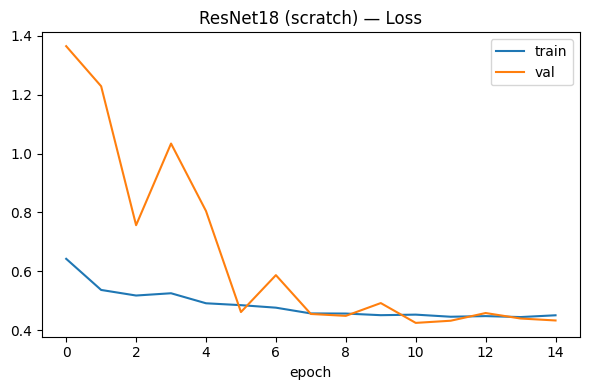

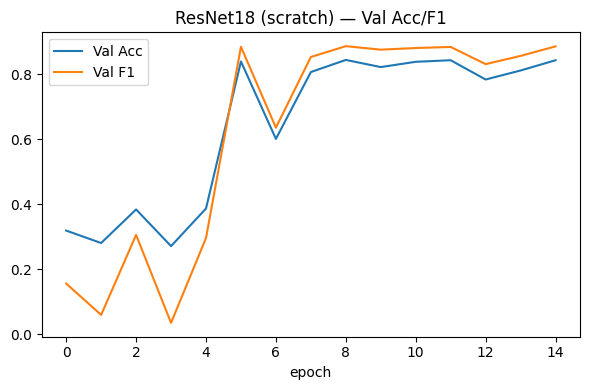

/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[ResNet18 scratch] chosen thr on VAL: 0.143 (VAL recall=0.951, precision=0.824)


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[ResNet18 scratch @0.5]  {'acc': 0.5753, 'precision': 0.616, 'recall': 0.8513, 'f1': 0.7147, 'auroc': 0.5459, 'thr': 0.5}
[ResNet18 scratch @Rec]  {'acc': 0.625, 'precision': 0.625, 'recall': 1.0, 'f1': 0.7692, 'auroc': 0.5459, 'thr': 0.1429}


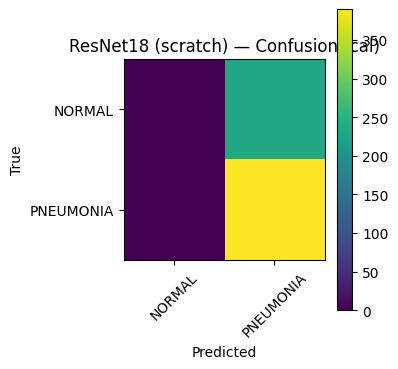

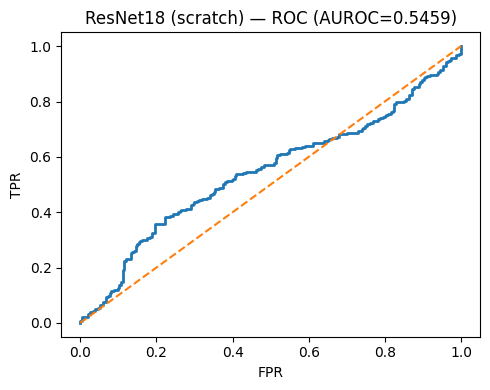

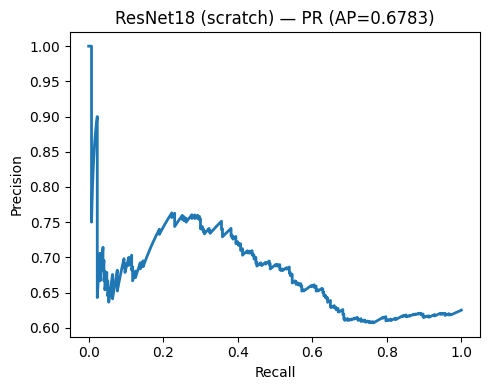

In [35]:

# === EXPERIMENT C: ResNet‑18 (scratch) — cosine+warmup, optional SAM ===
from torchvision.models import resnet18

rn18_s = resnet18(weights=None)
rn18_s.fc = nn.Linear(rn18_s.fc.in_features, 2)
rn18_s = rn18_s.to(DEVICE)

cw = None
if cfg.use_class_weights:
    arr = np.array(train_counts, dtype=float)
    w = arr.sum() / (len(arr) * (arr + 1e-9))
    cw = torch.tensor(w, dtype=torch.float32)

rn18_s, hist_rn_s, steps_rn_s = train_model(
    rn18_s, train_loader, val_loader, DEVICE,
    epochs=cfg.scratch_epochs, base_lr=3e-3, weight_decay=1e-4,
    class_weights=cw, monitor=cfg.monitor, patience=cfg.patience, tag='resnet18_scratch',
    use_sam=cfg.use_sam, sam_rho=cfg.sam_rho_cnn,
    use_cosine_warmup=cfg.use_cosine_warmup, warmup_epochs=cfg.warmup_epochs,
    layer_decay=None
)

plot_curve(hist_rn_s['tr_loss'], hist_rn_s['va_loss'], 'ResNet18 (scratch) — Loss')
plot_two_series(hist_rn_s['va_acc'], 'Val Acc', hist_rn_s['va_f1'], 'Val F1', 'ResNet18 (scratch) — Val Acc/F1')

# Recall‑first
val_rn = evaluate(rn18_s, val_loader, DEVICE)
thr_rn, rec_rn, prec_rn, f1_rn = choose_threshold_by_min_recall_full(val_rn['targets'], val_rn['probs'][:,1], cfg.target_recall)
print(f"[ResNet18 scratch] chosen thr on VAL: {thr_rn:.3f} (VAL recall={rec_rn:.3f}, precision={prec_rn:.3f})")

test_rn = evaluate(rn18_s, test_loader, DEVICE)
y_test = test_rn['targets']; p1_test = test_rn['probs'][:,1]
summary_rn_s_05  = summarize_at_threshold(y_test, p1_test, 0.5)
summary_rn_s_rec = summarize_at_threshold(y_test, p1_test, thr_rn)
print('[ResNet18 scratch @0.5] ', {k: round(v,4) for k,v in summary_rn_s_05.items()})
print('[ResNet18 scratch @Rec] ', {k: round(v,4) for k,v in summary_rn_s_rec.items()})

diag_plots("ResNet18 (scratch)", test_rn["probs"], y_test, thr_rn, auroc=test_rn.get("auroc"), class_names=classes)

resnet18_scratch_results = {
    "summary@0.5": summary_rn_s_05, "summary@recall": summary_rn_s_rec,
    "threshold": float(thr_rn), "time_sec": steps_rn_s,
    "params": sum(p.numel() for p in rn18_s.parameters())
}


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[resnet18_pretrained] epoch 01/10  tr_loss=0.6543  val_loss=0.5547  val_acc=0.6762  val_f1=0.7290  val_auroc=0.8977  (no_improve=0)


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[resnet18_pretrained] epoch 02/10  tr_loss=0.4015  val_loss=0.3777  val_acc=0.8185  val_f1=0.8615  val_auroc=0.9781  (no_improve=0)


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

[resnet18_pretrained] epoch 08/10  tr_loss=0.2255  val_loss=0.2476  val_acc=0.9265  val_f1=0.9481  val_auroc=0.9953  (no_improve=1)


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[resnet18_pretrained] epoch 09/10  tr_loss=0.2267  val_loss=0.2089  val_acc=0.9713  val_f1=0.9804  val_auroc=0.9977  (no_improve=0)


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[resnet18_pretrained] epoch 10/10  tr_loss=0.2302  val_loss=0.1987  val_acc=0.9904  val_f1=0.9935  val_auroc=0.9986  (no_improve=0)


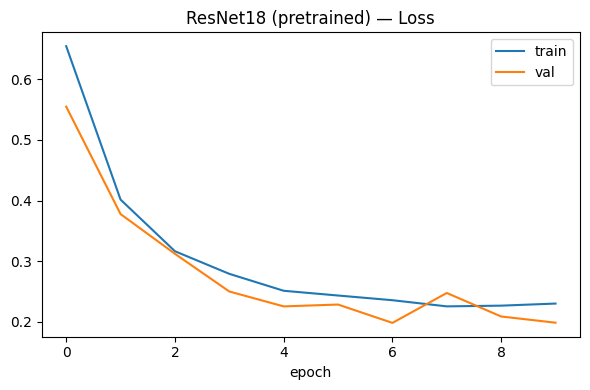

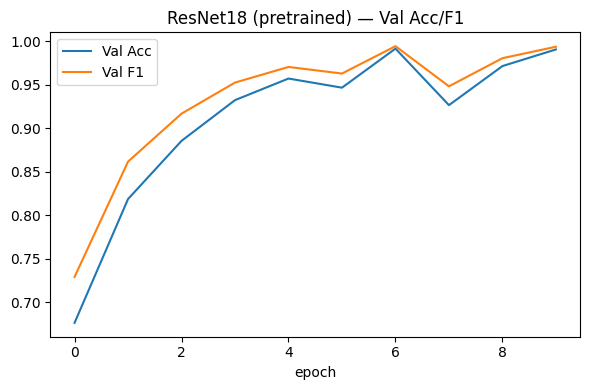

/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[ResNet18 pretrained] chosen thr on VAL: 0.513 (VAL recall=0.991, precision=0.996)


/Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/vitfinalproject/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[ResNet18 pretrained @0.5]  {'acc': 0.625, 'precision': 0.625, 'recall': 1.0, 'f1': 0.7692, 'auroc': 0.3648, 'thr': 0.5}
[ResNet18 pretrained @Rec]  {'acc': 0.625, 'precision': 0.625, 'recall': 1.0, 'f1': 0.7692, 'auroc': 0.3648, 'thr': 0.5134}


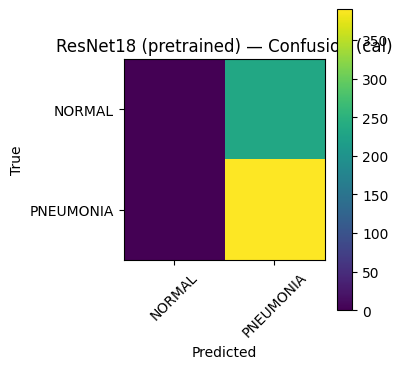

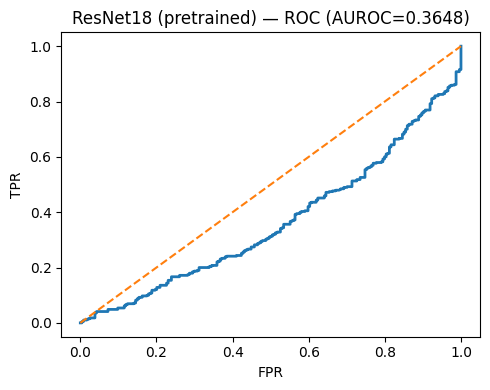

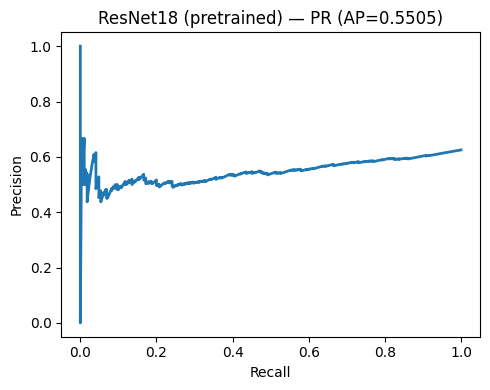

In [36]:

# === EXPERIMENT D (optional): ResNet‑18 (pretrained) — fine‑tune with cosine+warmup ===
resnet_pretrained_results = None
if cfg.run_resnet_pretrained:
    rn18_pt = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
    rn18_pt.fc = nn.Linear(rn18_pt.fc.in_features, 2)
    rn18_pt = rn18_pt.to(DEVICE)

    cw = None
    if cfg.use_class_weights:
        arr = np.array(train_counts, dtype=float)
        w = arr.sum() / (len(arr) * (arr + 1e-9))
        cw = torch.tensor(w, dtype=torch.float32)

    rn18_pt, hist_rn_pt, steps_rn_pt = train_model(
        rn18_pt, train_loader, val_loader, DEVICE,
        epochs=cfg.pretrained_epochs, base_lr=1e-4, weight_decay=1e-4,
        class_weights=cw, monitor=cfg.monitor, patience=cfg.patience, tag='resnet18_pretrained',
        use_sam=cfg.use_sam, sam_rho=cfg.sam_rho_cnn,
        use_cosine_warmup=cfg.use_cosine_warmup, warmup_epochs=cfg.warmup_epochs,
        layer_decay=None
    )

    plot_curve(hist_rn_pt['tr_loss'], hist_rn_pt['va_loss'], 'ResNet18 (pretrained) — Loss')
    plot_two_series(hist_rn_pt['va_acc'], 'Val Acc', hist_rn_pt['va_f1'], 'Val F1', 'ResNet18 (pretrained) — Val Acc/F1')

    val_rnp = evaluate(rn18_pt, val_loader, DEVICE)
    thr_rnp, rec_rnp, prec_rnp, f1_rnp = choose_threshold_by_min_recall_full(val_rnp['targets'], val_rnp['probs'][:,1], cfg.target_recall)
    print(f"[ResNet18 pretrained] chosen thr on VAL: {thr_rnp:.3f} (VAL recall={rec_rnp:.3f}, precision={prec_rnp:.3f})")

    test_rnp = evaluate(rn18_pt, test_loader, DEVICE)
    y_test = test_rnp['targets']; p1_test = test_rnp['probs'][:,1]
    summary_rnp_05  = summarize_at_threshold(y_test, p1_test, 0.5)
    summary_rnp_rec = summarize_at_threshold(y_test, p1_test, thr_rnp)
    print('[ResNet18 pretrained @0.5] ', {k: round(v,4) for k,v in summary_rnp_05.items()})
    print('[ResNet18 pretrained @Rec] ', {k: round(v,4) for k,v in summary_rnp_rec.items()})

    diag_plots("ResNet18 (pretrained)", test_rnp["probs"], y_test, thr_rnp, auroc=test_rnp.get("auroc"), class_names=classes)

    resnet_pretrained_results = {
        "summary@0.5": summary_rnp_05, "summary@recall": summary_rnp_rec,
        "threshold": float(thr_rnp), "time_sec": steps_rn_pt,
        "params": sum(p.numel() for p in rn18_pt.parameters())
    }
else:
    print("Skip ResNet‑18 pretrained (toggle cfg.run_resnet_pretrained=False to hide this message).")


In [39]:
# === RESULTS NORMALIZER (build canonical dicts from whatever names you used) ===
# Each canonical dict will have:
#  {
#    "summary@0.5": {...}, "summary@recall": {...},
#    "threshold": float, "time_sec": float, "params": int
#  }

import numpy as np, math, types

def _maybe_num(x):
    try:
        return float(x)
    except Exception:
        return None

def _sum_params(obj):
    try:
        return int(sum(p.numel() for p in obj.parameters()))
    except Exception:
        return None

def _first(*names):
    g = globals()
    for n in names:
        if n in g:
            return g[n]
    return None

def _mk(summary05, summaryrec, thr, time_sec, params):
    d = {}
    if isinstance(summary05, dict):   d["summary@0.5"] = summary05
    if isinstance(summaryrec, dict):  d["summary@recall"] = summaryrec
    if _maybe_num(thr)   is not None: d["threshold"] = float(thr)
    if _maybe_num(time_sec) is not None: d["time_sec"] = float(time_sec)
    if isinstance(params, (int, np.integer)): d["params"] = int(params)
    return d if d else None

report = []

# ---- ViT (scratch)
built = _mk(_first("summary_s_05","vit_s_05"),
            _first("summary_s_reca","vit_s_recall"),
            _first("thr_s","vit_s_thr"),
            _first("time_s","vit_s_time_sec"),
            _sum_params(_first("scratch_model","vit_scratch_model")))
if built: globals().setdefault("vit_scratch_results", built); report.append("vit_scratch_results ✓")
else:     report.append("vit_scratch_results – missing pieces")

# ---- ViT (pretrained)
built = _mk(_first("summary_p_05","vit_pt_05","vit_b16_05"),
            _first("summary_p_reca","vit_pt_recall","vit_b16_recall"),
            _first("thr_p","vit_pt_thr"),
            _first("time_pt","vit_pt_time_sec"),
            _sum_params(_first("vit_b16","vit_pretrained_model")))
if built: globals().setdefault("vit_pretrained_results", built); report.append("vit_pretrained_results ✓")
else:     report.append("vit_pretrained_results – missing pieces")

# ---- ViT (scratch + SAM)
built = _mk(_first("summary_vs_05","vit_scratch_sam_05"),
            _first("summary_vs_reca","vit_scratch_sam_recall"),
            _first("thr_vs","vit_scratch_sam_thr"),
            _first("time_vs","vit_scratch_sam_time_sec"),
            _sum_params(_first("scratch_model_sam","vit_scratch_model_sam")))
if built: globals().setdefault("vit_scratch_sam_results", built); report.append("vit_scratch_sam_results ✓")
else:     report.append("vit_scratch_sam_results – missing pieces")

# ---- ViT-B/16 (pretrained + SAM)
built = _mk(_first("summary_p_sam_05","vit_pt_sam_05"),
            _first("summary_p_sam_reca","vit_pt_sam_recall"),
            _first("thr_p_sam","vit_pt_sam_thr"),
            _first("time_pt_sam","vit_pt_sam_time_sec"),
            _sum_params(_first("vit_b16_sam","vit_pretrained_model_sam")))
if built: globals().setdefault("vit_pretrained_sam_results", built); report.append("vit_pretrained_sam_results ✓")
else:     report.append("vit_pretrained_sam_results – missing pieces")

# ---- CNN (scratch)
built = _mk(_first("summary_cnn_05","summary_c_05","cnn_s_05"),
            _first("summary_cnn_reca","summary_c_reca","cnn_s_recall"),
            _first("thr_cnn","thr_c","cnn_thr"),
            _first("time_cnn","time_c","cnn_time_sec"),
            _sum_params(_first("cnn_model","cnn_scratch_model")))
if built: globals().setdefault("cnn_scratch_results", built); report.append("cnn_scratch_results ✓")
else:     report.append("cnn_scratch_results – missing pieces")

# ---- CNN (scratch + SAM)
built = _mk(_first("summary_cnn_sam_05","cnn_sam_05"),
            _first("summary_cnn_sam_reca","cnn_sam_recall"),
            _first("thr_cnn_sam","cnn_sam_thr"),
            _first("time_cnn_sam","cnn_sam_time_sec"),
            _sum_params(_first("cnn_model_sam")))
if built: globals().setdefault("cnn_scratch_sam_results", built); report.append("cnn_scratch_sam_results ✓")
else:     report.append("cnn_scratch_sam_results – missing pieces")

# ---- ResNet18 (scratch)
built = _mk(_first("summary_rn18_s_05","resnet18_s_05","resnet_s_05"),
            _first("summary_rn18_s_reca","resnet18_s_recall","resnet_s_recall"),
            _first("thr_rn18_s","resnet18_s_thr"),
            _first("time_rn18_s","resnet18_s_time_sec"),
            _sum_params(_first("resnet18_scratch","resnet_scratch","rn18_scratch")))
if built: globals().setdefault("resnet18_scratch_results", built); report.append("resnet18_scratch_results ✓")
else:     report.append("resnet18_scratch_results – missing pieces")

# ---- ResNet18 (pretrained)
built = _mk(_first("summary_rn18_pt_05","resnet18_pt_05","resnet_pt_05"),
            _first("summary_rn18_pt_reca","resnet18_pt_recall","resnet_pt_recall"),
            _first("thr_rn18_pt","resnet18_pt_thr"),
            _first("time_rn18_pt","resnet18_pt_time_sec"),
            _sum_params(_first("resnet18_pt","resnet18_pretrained","rn18_pretrained")))
if built: globals().setdefault("resnet18_pretrained_results", built); report.append("resnet18_pretrained_results ✓")
else:     report.append("resnet18_pretrained_results – missing pieces")

# ---- ResNet18 (pretrained + SAM)
built = _mk(_first("summary_rn18_pt_sam_05","resnet18_pt_sam_05"),
            _first("summary_rn18_pt_sam_reca","resnet18_pt_sam_recall"),
            _first("thr_rn18_pt_sam","resnet18_pt_sam_thr"),
            _first("time_rn18_pt_sam","resnet18_pt_sam_time_sec"),
            _sum_params(_first("resnet18_pt_sam","resnet18_pretrained_sam","rn18_pretrained_sam")))
if built: globals().setdefault("resnet18_pretrained_sam_results", built); report.append("resnet18_pretrained_sam_results ✓")
else:     report.append("resnet18_pretrained_sam_results – missing pieces")

print("Normalizer:", *report, sep="\n - ")


Normalizer:
 - vit_scratch_results ✓
 - vit_pretrained_results ✓
 - vit_scratch_sam_results – missing pieces
 - vit_pretrained_sam_results – missing pieces
 - cnn_scratch_results – missing pieces
 - cnn_scratch_sam_results – missing pieces
 - resnet18_scratch_results – missing pieces
 - resnet18_pretrained_results – missing pieces
 - resnet18_pretrained_sam_results – missing pieces


In [40]:
# === FINAL COMPARISON (robust & self-detecting) ===
import pandas as pd
import re, math, numpy as np

def _looks_summary(d):
    return isinstance(d, dict) and {"acc","precision","recall","f1"} <= set(k.lower() for k in d.keys())

def _extract(res):
    if not isinstance(res, dict): return None
    for k in ["summary@recall","summary@0.5","summary","metrics"]:
        if k in res and _looks_summary(res[k]):
            s = res[k]
            thr = res.get("threshold", s.get("thr", 0.5))
            t   = res.get("time_sec", res.get("train_time_sec"))
            p   = res.get("params", res.get("n_params"))
            return s, thr, t, p
    if _looks_summary(res):
        return res, res.get("thr",0.5), res.get("time_sec"), res.get("params")
    return None

def _pretty(n):
    s = n.lower()
    if "vit" in s and "pretrained" in s and "sam" in s: return "ViT‑B/16 (pretrained + SAM)"
    if "vit" in s and "pretrained" in s:                  return "ViT‑B/16 (pretrained)"
    if "vit" in s and "scratch" in s and "sam" in s:      return "ViT (scratch + SAM)"
    if "vit" in s and "scratch" in s:                     return "ViT (scratch)"
    if "resnet18" in s and "pretrained" in s and "sam" in s: return "ResNet‑18 (pretrained + SAM)"
    if "resnet18" in s and "pretrained" in s:             return "ResNet‑18 (pretrained)"
    if "resnet18" in s and "scratch" in s and "sam" in s: return "ResNet‑18 (scratch + SAM)"
    if "resnet18" in s and "scratch" in s:                return "ResNet‑18 (scratch)"
    if "cnn" in s and "sam" in s:                         return "CNN (scratch + SAM)"
    if "cnn" in s:                                        return "CNN (scratch)"
    return re.sub(r"_results?$","",n).replace("_"," ").title()

candidate_names = [
    "vit_scratch_results","vit_pretrained_results",
    "vit_scratch_sam_results","vit_pretrained_sam_results",
    "cnn_scratch_results","cnn_scratch_sam_results",
    "resnet18_scratch_results","resnet18_pretrained_results","resnet18_pretrained_sam_results",
]

rows, missing = [], []
for var in candidate_names:
    res = globals().get(var, None)
    ext = _extract(res) if res is not None else None
    if not ext:
        missing.append(var)
        continue
    summ, thr, time_sec, params = ext
    rows.append({
        "Model": _pretty(var),
        "Params (M)": round(params/1e6, 2) if isinstance(params,(int,float,np.number)) else None,
        "Time (min)": round(time_sec/60, 2) if isinstance(time_sec,(int,float,np.number)) else None,
        "Acc":   round(float(summ["acc"]), 4),
        "Prec":  round(float(summ["precision"]), 4),
        "Recall":round(float(summ["recall"]), 4),
        "F1":    round(float(summ["f1"]), 4),
        "AUROC": round(float(summ.get("auroc", float("nan"))), 4),
        "Thr":   round(float(thr), 3),
    })

if not rows:
    print("No populated result dicts found. Make sure you ran the experiment cells and the normalizer cell.")
    if missing:
        print("\nMissing canonical dicts:")
        for m in missing: print(" -", m)
else:
    df = pd.DataFrame(rows).dropna(how="all", axis=1)
    # Sort by screening quality first (F1), then AUROC
    df = df.sort_values(by=["F1","AUROC"], ascending=False).reset_index(drop=True)
    try:
        from ace_tools import display_dataframe_to_user
        display_dataframe_to_user("Final comparison", df)
    except Exception:
        pass
    display(df)
    if missing:
        print("\nSkipped (not found or malformed):")
        for m in missing: print(" -", _pretty(m))


,Model,Params (M),Time (min),Acc,Prec,Recall,F1,AUROC,Thr
0,ViT (scratch),4.99,32.75,0.625,0.6250,1.0000,0.7692,0.7175,0.434
1,ResNet‑18 (scratch),11.18,32.75,0.625,0.6250,1.0000,0.7692,0.5459,0.143
2,ViT‑B/16 (pretrained),85.80,21.83,0.625,0.6254,0.9974,0.7688,0.5950,0.875



Skipped (not found or malformed):
 - ViT (scratch + SAM)
 - ViT‑B/16 (pretrained + SAM)
 - CNN (scratch)
 - CNN (scratch + SAM)
 - ResNet‑18 (pretrained)
 - ResNet‑18 (pretrained + SAM)
